# Paint-By-Numbers Pipeline

A full image-to-paint-by-numbers pipeline using **OpenCV**, **NumPy**,
**scikit-learn**, and **Matplotlib**.

## Pipeline Overview

```
Load Image → Preprocess → Color Quantization → Color Masks → Extract Contours
    → Simplify Contours → Draw Outline → Generate Palette → Export Assets
```

## Dependencies

```bash
pip install opencv-python numpy scikit-learn matplotlib ipywidgets
```


In [13]:
import io
import math
from pathlib import Path
from typing import List, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

%matplotlib inline
plt.rcParams["figure.dpi"] = 100


In [14]:
# ── Tweakable parameters ─────────────────────────────────────────────────────
IMAGE_PATH        = "/Users/monahengramokhoro/projects/python/paintober/v0.1/download.png"  # ← set your image path here
K_COLORS          = 12     # number of paint colors
MIN_REGION_AREA   = 200    # minimum pixel area to keep a region
CONTOUR_EPSILON   = 0.002  # contour simplification (fraction of perimeter)
LINE_THICKNESS    = 1      # outline stroke width (px)
APPLY_GAUSSIAN    = True   # toggle additional Gaussian blur after bilateral
MIN_LABEL_SPACING = 12     # minimum pixel distance between any two label centres
OUTPUT_DIR        = Path("../outputs")


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper Functions
# ─────────────────────────────────────────────────────────────────────────────


def load_image(path: str) -> np.ndarray:
    '''Load an image from disk, convert BGR→RGB, and resize if width > 1500 px.

    Parameters
    ----------
    path : str
        File-system path to the image (JPEG, PNG, etc.).

    Returns
    -------
    np.ndarray
        RGB image array of shape (H, W, 3), dtype uint8.
    '''
    bgr = cv2.imread(path)
    if bgr is None:
        raise FileNotFoundError(f"Could not load image: {path!r}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]
    if w > 1500:
        scale = 1500 / w
        rgb = cv2.resize(rgb, (1500, int(h * scale)), interpolation=cv2.INTER_AREA)
    return rgb


def preprocess_image(img: np.ndarray, apply_gaussian: bool = False) -> np.ndarray:
    '''Smooth the image while preserving edges using a bilateral filter.

    Bilateral filtering weights neighbours by both spatial distance *and*
    colour similarity, so it smooths flat areas while leaving edges intact.
    An optional Gaussian pass can further reduce noise on very grainy inputs.

    Parameters
    ----------
    img : np.ndarray
        RGB input image, uint8.
    apply_gaussian : bool
        If True, applies a mild Gaussian blur after the bilateral filter.

    Returns
    -------
    np.ndarray
        Smoothed RGB image, uint8.
    '''
    smoothed = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)
    if apply_gaussian:
        smoothed = cv2.GaussianBlur(smoothed, (5, 5), 0)
    return smoothed


def quantize_colors(
    img: np.ndarray, k: int = 12
) -> Tuple[np.ndarray, np.ndarray]:
    '''Reduce the image to k colours using K-Means clustering.

    Each pixel is assigned to the nearest cluster centroid, producing a
    simplified image whose pixels take exactly k distinct RGB values.

    Parameters
    ----------
    img : np.ndarray
        RGB input image, uint8.
    k : int
        Number of colours (clusters).

    Returns
    -------
    quantized_img : np.ndarray
        Image with pixels replaced by their cluster centroid, uint8.
    palette : np.ndarray
        Array of shape (k, 3) with the k centroid colours, uint8.
    '''
    h, w = img.shape[:2]
    pixels = img.reshape(-1, 3).astype(np.float32)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pixels)
    palette = kmeans.cluster_centers_.astype(np.uint8)
    quantized_img = palette[kmeans.labels_].reshape(h, w, 3)
    return quantized_img, palette


def create_color_masks(
    quantized_img: np.ndarray, palette: np.ndarray
) -> List[np.ndarray]:
    '''Create a binary mask for each palette colour and clean it morphologically.

    For each colour, pixels are matched exactly (safe because quantized pixels
    are reconstructed from palette uint8 values). Morphological opening removes
    small noise; closing fills small holes.

    Parameters
    ----------
    quantized_img : np.ndarray
        Quantized RGB image — pixels are exact palette values.
    palette : np.ndarray
        Array of shape (k, 3), uint8.

    Returns
    -------
    List[np.ndarray]
        List of k binary masks (uint8, values 0 or 255), one per colour.
    '''
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    masks: List[np.ndarray] = []
    for color in palette:
        mask = np.all(quantized_img == color, axis=2).astype(np.uint8) * 255
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        masks.append(mask)
    return masks


def extract_contours(
    masks: List[np.ndarray], min_area: int = 200
) -> List[List[np.ndarray]]:
    '''Find external contours for each colour mask, filtering small noise.

    Parameters
    ----------
    masks : List[np.ndarray]
        Binary masks, one per palette colour.
    min_area : int
        Minimum contour area in pixels; smaller contours are discarded.

    Returns
    -------
    List[List[np.ndarray]]
        Outer list — one entry per colour; inner list — cv2 contour arrays.
    '''
    contours_by_color: List[List[np.ndarray]] = []
    for mask in masks:
        cnts, _ = cv2.findContours(
            mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        filtered = [c for c in cnts if cv2.contourArea(c) >= min_area]
        contours_by_color.append(filtered)
    return contours_by_color


def simplify_contours(
    contours_by_color: List[List[np.ndarray]],
    epsilon_ratio: float = 0.002,
) -> List[List[np.ndarray]]:
    '''Simplify contour polygons using the Ramer-Douglas-Peucker algorithm.

    Epsilon is computed as a fraction of each contour's perimeter so that
    simplification adapts to shape size. Larger epsilon → fewer vertices →
    simpler, more paint-friendly shapes.

    Parameters
    ----------
    contours_by_color : List[List[np.ndarray]]
        Raw contours grouped by palette colour.
    epsilon_ratio : float
        Fraction of each contour's perimeter used as the approximation
        tolerance (e.g. 0.002 = 0.2 % of perimeter).

    Returns
    -------
    List[List[np.ndarray]]
        Simplified contours, same nested structure as input.
    '''
    simplified: List[List[np.ndarray]] = []
    for contours in contours_by_color:
        simp_group: List[np.ndarray] = []
        for c in contours:
            eps = epsilon_ratio * cv2.arcLength(c, True)
            approx = cv2.approxPolyDP(c, eps, True)
            simp_group.append(approx)
        simplified.append(simp_group)
    return simplified


def _find_label_point(contour: np.ndarray, image_shape: Tuple[int, int]) -> Tuple[int, int]:
    '''Find the interior point of a contour most distant from its edges.

    Uses a distance transform on a filled contour mask to locate the
    "pole of inaccessibility" — the point inside the shape furthest from
    all boundaries. This guarantees the label lands inside the region even
    for concave or crescent-shaped contours where the geometric centroid
    would fall outside.

    Parameters
    ----------
    contour : np.ndarray
        Single cv2 contour array.
    image_shape : Tuple[int, int]
        (height, width) of the full image, used to size the temporary mask.

    Returns
    -------
    Tuple[int, int]
        (x, y) pixel coordinates of the best interior label position.
    '''
    h, w = image_shape
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, cv2.FILLED)
    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
    _, _, _, max_loc = cv2.minMaxLoc(dist)
    return max_loc  # (x, y)


def draw_outline(
    contours_by_color: List[List[np.ndarray]],
    image_shape: Tuple[int, int],
    thickness: int = 2,
    min_label_area: int = 200,
    min_label_spacing: int = 12,
) -> np.ndarray:
    '''Draw black contour lines and region numbers on a white canvas.

    Region numbers correspond to palette indices so painters know which
    colour to use.

    Label placement uses three strategies to avoid crowding:

    1. **Guaranteed-inside point**: the label is positioned at the pole of
       inaccessibility (distance-transform maximum), which is always inside
       the region — even for concave or crescent shapes.
    2. **Global occupancy check**: a single list of placed label centres is
       maintained across *all* colour groups. A new label is only drawn if
       no existing label is within ``min_label_spacing`` pixels, preventing
       cross-colour collisions.
    3. **Area-proportional font size**: the font scale grows with
       ``sqrt(area)`` so tiny regions receive smaller (or no) text, reducing
       visual clutter without raising ``min_label_area``.

    Parameters
    ----------
    contours_by_color : List[List[np.ndarray]]
        Simplified contours grouped by palette colour.
    image_shape : Tuple[int, int]
        (height, width) of the output image.
    thickness : int
        Stroke width for contour lines in pixels.
    min_label_area : int
        Minimum contour area to place a number label.
    min_label_spacing : int
        Minimum Euclidean distance in pixels between any two label centres.

    Returns
    -------
    np.ndarray
        White RGB canvas with black outlines and grey region numbers, uint8.
    '''
    h, w = image_shape
    canvas = np.ones((h, w, 3), dtype=np.uint8) * 255

    # Draw all contour lines first so labels are rendered on top.
    for contours in contours_by_color:
        cv2.drawContours(canvas, contours, -1, (0, 0, 0), thickness)

    # Global list of placed label centres — shared across all colour groups.
    placed: List[Tuple[int, int]] = []

    for color_idx, contours in enumerate(contours_by_color):
        label = str(color_idx + 1)
        for c in contours:
            area = cv2.contourArea(c)
            if area < min_label_area:
                continue

            # 1. Find guaranteed-inside label point via distance transform.
            lx, ly = _find_label_point(c, (h, w))

            # 2. Reject if too close to any already-placed label.
            too_close = any(
                math.hypot(lx - px, ly - py) < min_label_spacing
                for px, py in placed
            )
            if too_close:
                continue

            # 3. Area-proportional font scale (clamped to [0.25, 0.55]).
            font_scale = max(0.25, min(0.55, math.sqrt(area) / 200))

            cv2.putText(
                canvas,
                label,
                (lx, ly),
                cv2.FONT_HERSHEY_SIMPLEX,
                font_scale,
                (60, 60, 60),
                1,
                cv2.LINE_AA,
            )
            placed.append((lx, ly))

    return canvas


def create_palette_image(palette: np.ndarray) -> np.ndarray:
    '''Render the colour palette as a row of labelled swatches.

    Each swatch shows: colour block, index number, RGB values, and a
    placeholder paint-mixing note.

    Parameters
    ----------
    palette : np.ndarray
        Array of shape (k, 3), uint8, RGB colours.

    Returns
    -------
    np.ndarray
        Palette image as an RGB numpy array, uint8.
    '''
    k = len(palette)
    fig, axes = plt.subplots(1, k, figsize=(max(k * 1.5, 6), 2.5))
    if k == 1:
        axes = [axes]
    for i, (ax, color) in enumerate(zip(axes, palette)):
        r, g, b = int(color[0]), int(color[1]), int(color[2])
        ax.set_facecolor(tuple(c / 255 for c in (r, g, b)))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"#{i + 1}", fontsize=9, pad=3)
        luminance = r * 0.299 + g * 0.587 + b * 0.114
        text_color = "white" if luminance < 128 else "black"
        ax.text(
            0.5, 0.62,
            f"RGB\n({r},{g},{b})",
            ha="center", va="center",
            fontsize=6.5, color=text_color,
            transform=ax.transAxes,
        )
        ax.text(
            0.5, 0.22,
            f"Mix approx\nRGB({r},{g},{b})",
            ha="center", va="center",
            fontsize=5.5, color=text_color,
            transform=ax.transAxes,
        )
    fig.suptitle("Color Palette", fontsize=11, y=1.02)
    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=100)
    plt.show()
    buf.seek(0)
    arr = np.frombuffer(buf.read(), dtype=np.uint8)
    palette_img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    palette_img = cv2.cvtColor(palette_img, cv2.COLOR_BGR2RGB)
    buf.close()
    return palette_img


def export_assets(
    quantized_img: np.ndarray,
    outline: np.ndarray,
    palette_img: np.ndarray,
    output_dir: Path,
) -> None:
    '''Save the three pipeline outputs to disk.

    Parameters
    ----------
    quantized_img : np.ndarray
        Colour-quantized RGB image.
    outline : np.ndarray
        Black-on-white outline RGB image.
    palette_img : np.ndarray
        Palette swatch RGB image.
    output_dir : Path
        Directory to write outputs into (created if absent).
    '''
    output_dir.mkdir(parents=True, exist_ok=True)
    assets = {
        "quantized_color.png": cv2.cvtColor(quantized_img, cv2.COLOR_RGB2BGR),
        "outline.png":         cv2.cvtColor(outline, cv2.COLOR_RGB2BGR),
        "palette.png":         cv2.cvtColor(palette_img, cv2.COLOR_RGB2BGR),
    }
    for filename, img_bgr in assets.items():
        out_path = output_dir / filename
        cv2.imwrite(str(out_path), img_bgr)
        print(f"Saved → {out_path.resolve()}")


---
## Step 1 — Load Image

Load the photo from disk, convert from OpenCV's BGR colour order to RGB, and
resize if the width exceeds 1 500 px to keep processing fast.


Image shape: (722, 1080, 3)  dtype: uint8


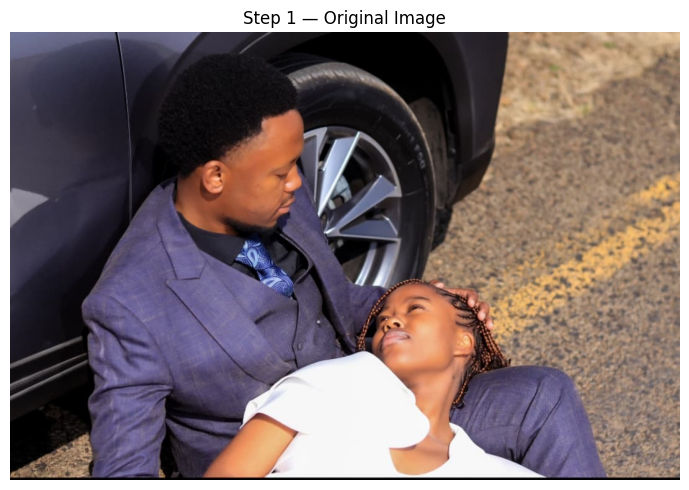

In [16]:
img = load_image(IMAGE_PATH)
print(f"Image shape: {img.shape}  dtype: {img.dtype}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(img)
ax.set_title("Step 1 — Original Image")
ax.axis("off")
plt.tight_layout()
plt.show()


---
## Step 2 — Pre-processing

**Why bilateral filtering?**

Unlike Gaussian blur — which treats every pixel equally — bilateral filtering
weights neighbours by both *spatial distance* **and** *colour similarity*.
This smooths flat colour areas aggressively while leaving edges almost
untouched, which is ideal for paint-by-numbers where crisp region boundaries
matter.

| Parameter | Value | Effect |
|-----------|-------|--------|
| `d=9` | 9 px neighbourhood diameter | Controls how many pixels are considered |
| `sigmaColor=75` | colour tolerance | Pixels differing by more than ~75 in colour are not blended |
| `sigmaSpace=75` | spatial tolerance | Pixels farther than ~75 px have little influence |


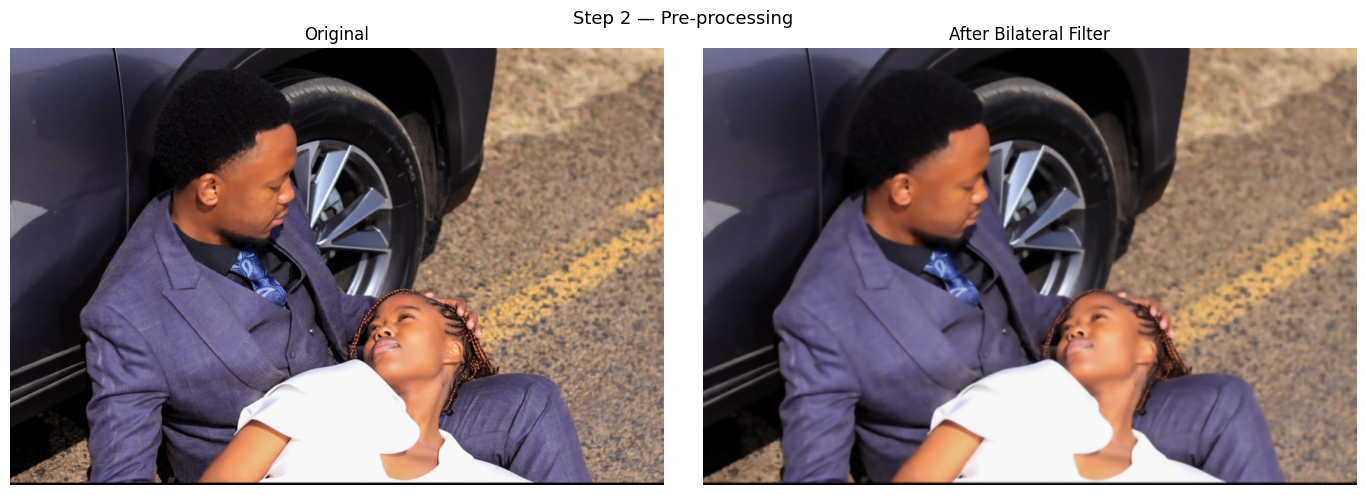

In [17]:
preprocessed = preprocess_image(img, apply_gaussian=APPLY_GAUSSIAN)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(preprocessed)
axes[1].set_title("After Bilateral Filter")
axes[1].axis("off")
plt.suptitle("Step 2 — Pre-processing", fontsize=13)
plt.tight_layout()
plt.show()


---
## Step 3 — Color Quantization

Color quantization reduces the number of unique colours in the image by
clustering all pixels into **K** groups using K-Means. Each pixel is replaced
by its cluster centroid colour, giving a simplified palette of exactly K
colours.

> **Tip:** Increase `K_COLORS` for more detail; decrease it for a simpler,
> easier-to-paint result.  12 is a good starting point for most photos.


Palette (12 colors):
  # 1  RGB(196, 116,  81)
  # 2  RGB( 35,  30,  38)
  # 3  RGB(244, 244, 245)
  # 4  RGB( 86,  78, 107)
  # 5  RGB(219, 165, 120)
  # 6  RGB( 11,   9,  12)
  # 7  RGB(167, 139, 114)
  # 8  RGB(109, 101, 143)
  # 9  RGB( 60,  54,  69)
  #10  RGB(131,  79,  60)
  #11  RGB(144, 120, 102)
  #12  RGB(168, 174, 195)


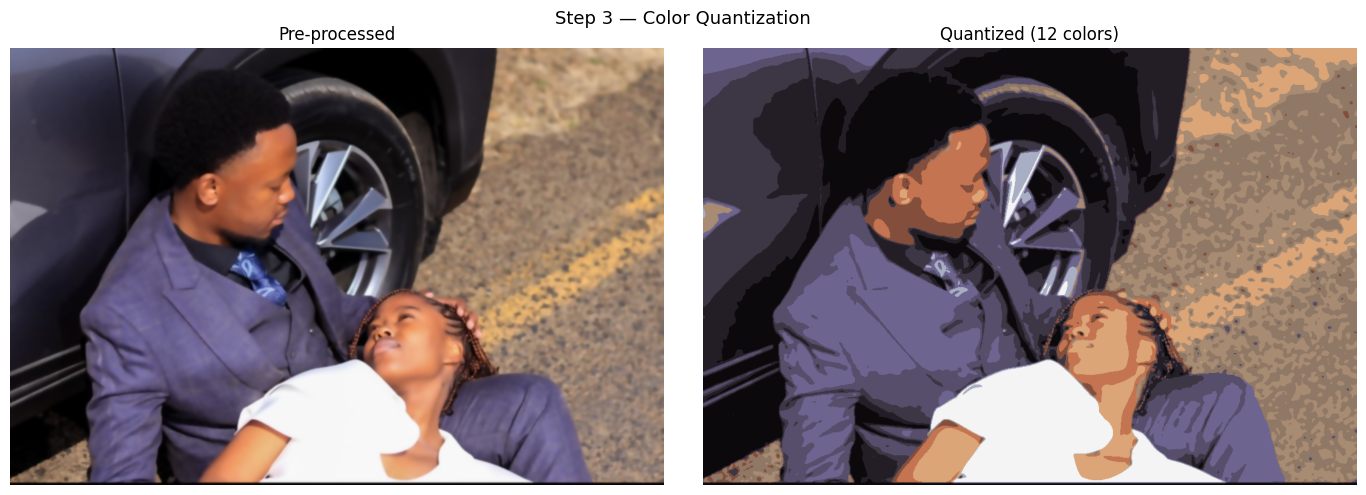

In [18]:
quantized, palette = quantize_colors(preprocessed, k=K_COLORS)

print(f"Palette ({K_COLORS} colors):")
for i, c in enumerate(palette):
    print(f"  #{i + 1:>2}  RGB({c[0]:>3}, {c[1]:>3}, {c[2]:>3})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(preprocessed)
axes[0].set_title("Pre-processed")
axes[0].axis("off")
axes[1].imshow(quantized)
axes[1].set_title(f"Quantized ({K_COLORS} colors)")
axes[1].axis("off")
plt.suptitle("Step 3 — Color Quantization", fontsize=13)
plt.tight_layout()
plt.show()


---
## Step 4 — Color Masks

Each palette colour is turned into a binary mask — white where that colour
appears, black elsewhere.

- **Morphological opening** (erosion → dilation) removes isolated noise pixels.
- **Morphological closing** (dilation → erosion) fills small holes inside
  regions.

Both operations use a 3×3 elliptical structuring element.


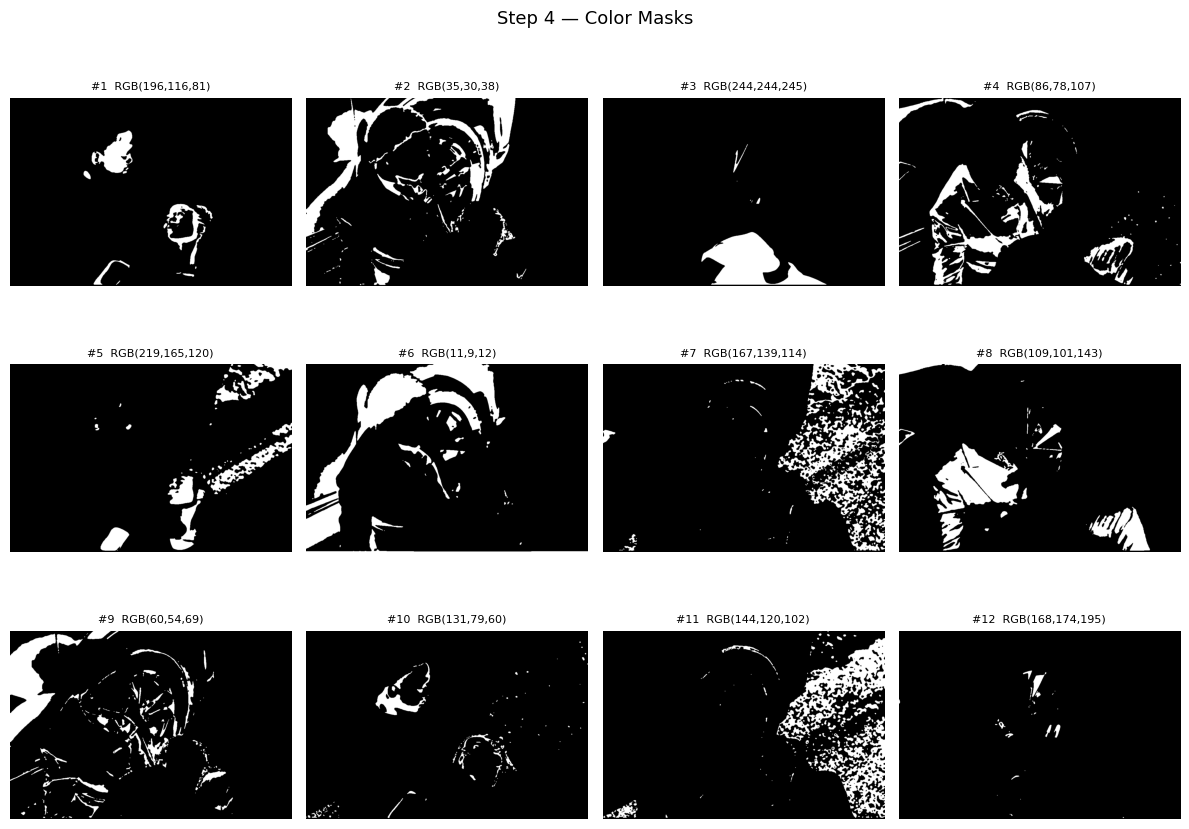

In [19]:
masks = create_color_masks(quantized, palette)

cols = 4
rows = math.ceil(K_COLORS / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes_flat = np.array(axes).flatten()

for i, (mask, ax) in enumerate(zip(masks, axes_flat)):
    r, g, b = int(palette[i][0]), int(palette[i][1]), int(palette[i][2])
    ax.imshow(mask, cmap="gray")
    ax.set_title(f"#{i + 1}  RGB({r},{g},{b})", fontsize=8)
    ax.axis("off")
for ax in axes_flat[len(masks):]:
    ax.axis("off")

plt.suptitle("Step 4 — Color Masks", fontsize=13)
plt.tight_layout()
plt.show()


---
## Step 5 — Extract Contours

`cv2.findContours` traces the boundary of each white region in a mask.

- `RETR_EXTERNAL` retrieves only outer boundaries (ignores holes inside shapes).
- `CHAIN_APPROX_SIMPLE` compresses horizontal/vertical/diagonal runs into
  endpoints, reducing memory.
- Contours smaller than `MIN_REGION_AREA` pixels are discarded as noise.


Total contours found: 188


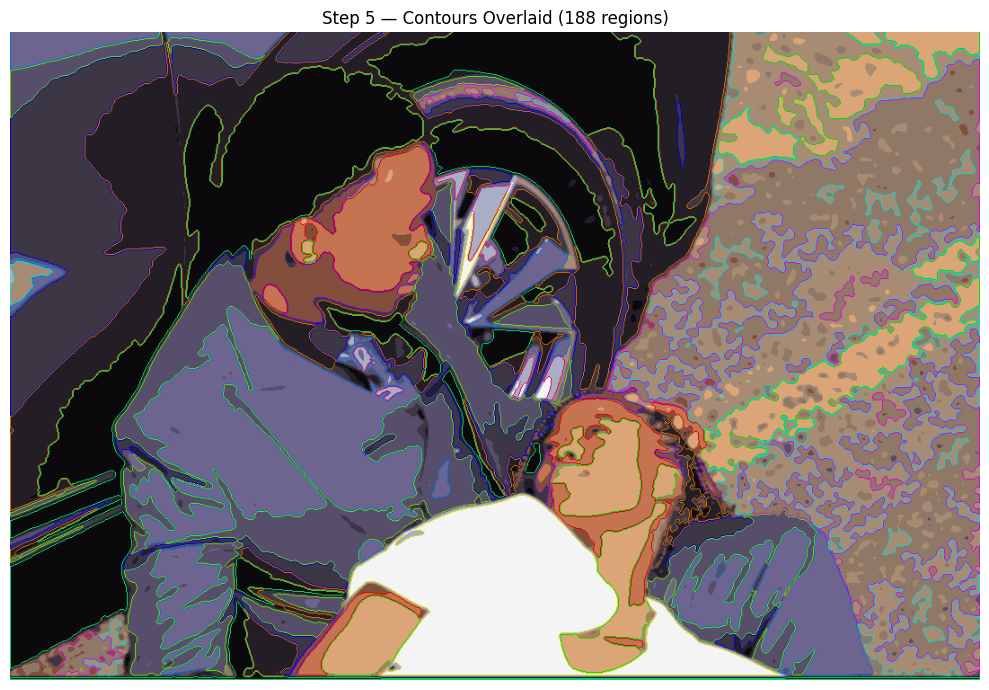

In [20]:
contours_by_color = extract_contours(masks, min_area=MIN_REGION_AREA)
total_contours = sum(len(c) for c in contours_by_color)
print(f"Total contours found: {total_contours}")

# Visualise contours overlaid on quantized image
overlay = quantized.copy()
for color_idx, contours in enumerate(contours_by_color):
    hue = int(color_idx * 180 / max(K_COLORS, 1))
    hsv_color = np.uint8([[[hue, 255, 220]]])
    bgr_color = cv2.cvtColor(hsv_color, cv2.COLOR_HSV2BGR)[0][0]
    rgb_color = (int(bgr_color[2]), int(bgr_color[1]), int(bgr_color[0]))
    cv2.drawContours(overlay, contours, -1, rgb_color, 1)

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(overlay)
ax.set_title(f"Step 5 — Contours Overlaid ({total_contours} regions)")
ax.axis("off")
plt.tight_layout()
plt.show()


---
## Step 6 — Contour Simplification

Raw contours from pixel-level operations can have thousands of vertices — far
too complex for a hand-painted template. The **Ramer–Douglas–Peucker**
algorithm (`cv2.approxPolyDP`) reduces vertex count while preserving the
overall shape.

### How epsilon works

```
epsilon = epsilon_ratio × perimeter
```

- The ratio makes epsilon **adaptive**: large shapes get larger tolerances,
  small shapes get smaller ones.
- `0.002` (0.2 % of perimeter) is conservative — shapes remain recognisable.
- Increasing to `0.005–0.01` produces blockier, more stylised results.


Vertices before: 34,557
Vertices after:  10,544  (69.5% reduction)


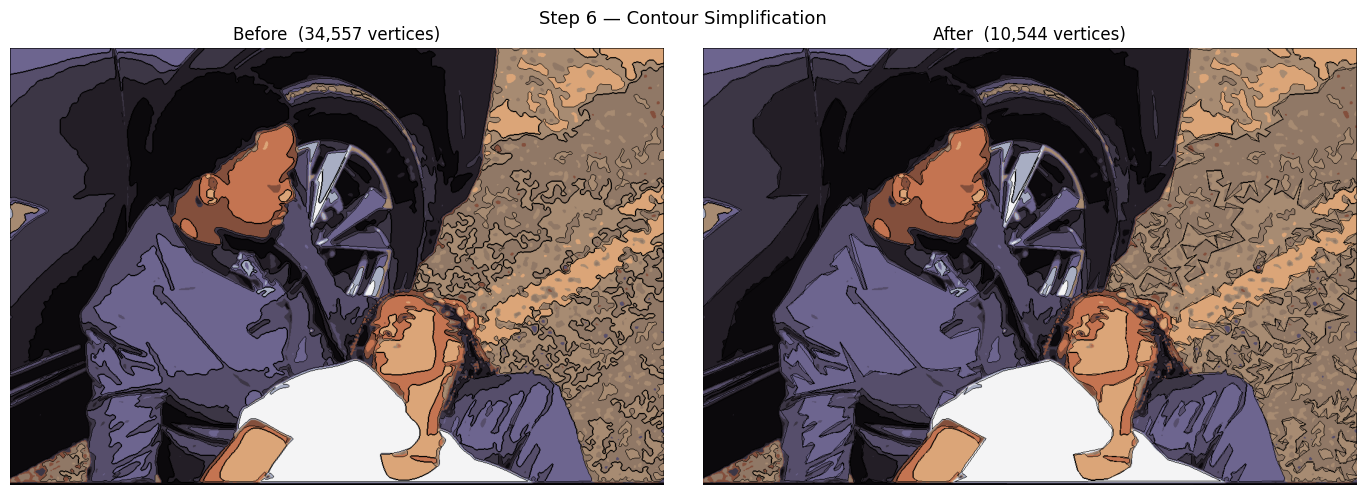

In [21]:
simplified = simplify_contours(contours_by_color, epsilon_ratio=CONTOUR_EPSILON)

before_pts = sum(c.shape[0] for group in contours_by_color for c in group)
after_pts  = sum(c.shape[0] for group in simplified       for c in group)
reduction  = 100 * (1 - after_pts / max(before_pts, 1))
print(f"Vertices before: {before_pts:,}")
print(f"Vertices after:  {after_pts:,}  ({reduction:.1f}% reduction)")

h_img, w_img = quantized.shape[:2]
canvas_before = quantized.copy()
canvas_after  = quantized.copy()
for group in contours_by_color:
    cv2.drawContours(canvas_before, group, -1, (0, 0, 0), 1)
for group in simplified:
    cv2.drawContours(canvas_after, group, -1, (0, 0, 0), 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(canvas_before)
axes[0].set_title(f"Before  ({before_pts:,} vertices)")
axes[0].axis("off")
axes[1].imshow(canvas_after)
axes[1].set_title(f"After  ({after_pts:,} vertices)")
axes[1].axis("off")
plt.suptitle("Step 6 — Contour Simplification", fontsize=13)
plt.tight_layout()
plt.show()


---
## Step 7 — Outline Image

The outline is the printable paint-by-numbers template: a white canvas with
black region borders and a small number inside each region identifying which
palette colour to use.

Numbers are placed at the **centroid** of each region's contour (computed via
image moments). Regions smaller than `MIN_REGION_AREA` are left unnumbered to
avoid visual clutter.


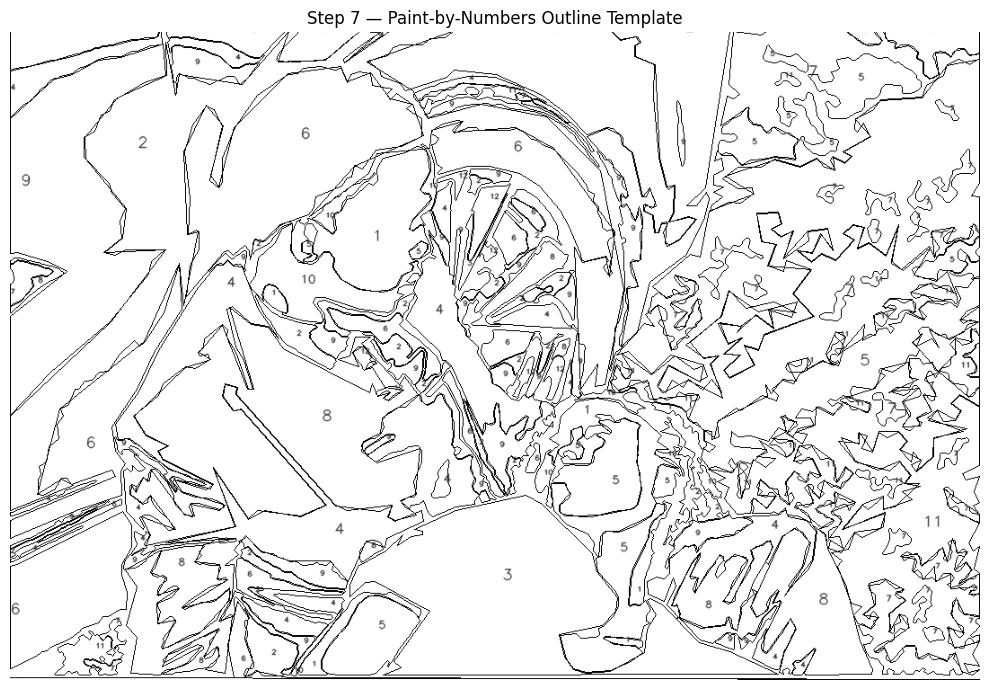

In [22]:
h_img, w_img = quantized.shape[:2]
outline = draw_outline(
    simplified,
    (h_img, w_img),
    thickness=LINE_THICKNESS,
    min_label_area=MIN_REGION_AREA,
    min_label_spacing=MIN_LABEL_SPACING,
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(outline)
ax.set_title("Step 7 — Paint-by-Numbers Outline Template")
ax.axis("off")
plt.tight_layout()
plt.show()


---
## Step 8 — Color Palette

Each swatch is labelled with:
- Its **number** (matching the outline)
- The **RGB values**
- A placeholder **paint-mixing note** (in a real workflow this could reference a
  specific paint brand colour code)


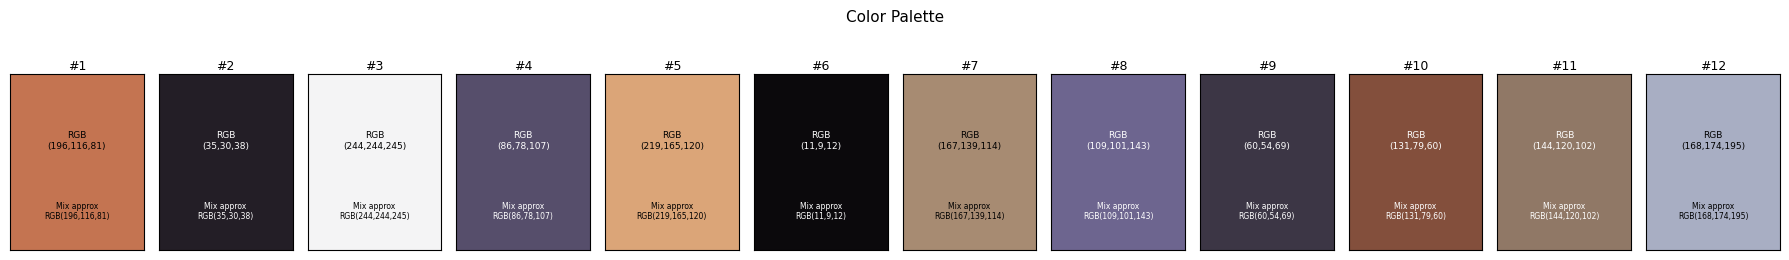

Palette image shape: (260, 1789, 3)


In [23]:
palette_img = create_palette_image(palette)
print(f"Palette image shape: {palette_img.shape}")


---
## Step 9 — Export Assets

Three files are written to the `outputs/` folder at the project root:

| File | Contents |
|------|----------|
| `quantized_color.png` | Simplified colour reference |
| `outline.png` | Printable paint-by-numbers template |
| `palette.png` | Colour swatches with numbers |


In [24]:
export_assets(quantized, outline, palette_img, OUTPUT_DIR)


Saved → /Users/monahengramokhoro/projects/python/paintober/outputs/quantized_color.png
Saved → /Users/monahengramokhoro/projects/python/paintober/outputs/outline.png
Saved → /Users/monahengramokhoro/projects/python/paintober/outputs/palette.png


---
## Bonus — Interactive Controls (ipywidgets)

Adjust the sliders to re-run the pipeline with different settings. Release a
slider to trigger an update (`continuous_update=False` prevents re-running on
every tick).

> **Note:** Each update re-runs KMeans clustering — this may take 5–15 seconds
> depending on image size and the number of colours selected.


In [ ]:
try:
    import ipywidgets as widgets

    def _run_pipeline(k: int, min_area: int, epsilon: float, min_spacing: int) -> None:
        q, pal = quantize_colors(preprocessed, k=k)
        m = create_color_masks(q, pal)
        cnts = extract_contours(m, min_area=min_area)
        simp = simplify_contours(cnts, epsilon_ratio=epsilon)
        h_, w_ = q.shape[:2]
        out = draw_outline(
            simp, (h_, w_),
            thickness=LINE_THICKNESS,
            min_label_area=min_area,
            min_label_spacing=min_spacing,
        )
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        axes[0].imshow(q)
        axes[0].set_title(f"Quantized (k={k})")
        axes[0].axis("off")
        axes[1].imshow(out)
        axes[1].set_title("Outline")
        axes[1].axis("off")
        plt.tight_layout()
        plt.show()
        create_palette_image(pal)

    widgets.interact(
        _run_pipeline,
        k=widgets.IntSlider(
            value=K_COLORS, min=4, max=24, step=2,
            description="Colors", continuous_update=False,
        ),
        min_area=widgets.IntSlider(
            value=MIN_REGION_AREA, min=50, max=500, step=50,
            description="Min Area", continuous_update=False,
        ),
        epsilon=widgets.FloatSlider(
            value=CONTOUR_EPSILON, min=0.001, max=0.010, step=0.001,
            description="Epsilon", readout_format=".3f",
            continuous_update=False,
        ),
        min_spacing=widgets.IntSlider(
            value=MIN_LABEL_SPACING, min=4, max=40, step=2,
            description="Spacing", continuous_update=False,
        ),
    )
except ImportError:
    print("ipywidgets not installed. Run: pip install ipywidgets")
